# Modeling
## Home Credit Default Risk

### 1. Purpose of This Notebook:  Baseline Modeling

This notebook establishes a **baseline model for the Home Credit Default Risk project** using Logistic Regression and the features selected during the exploratory analysis.

The goal is not to build a final model, but to create a simple and interpretable benchmark to assess the current predictive signal and identify the main opportunities for improvement.

The analysis focuses on:

- Baseline performance using ROC-AUC, PR-AUC, precision, recall, and F1-score;
- Model behavior under class imbalance;
- Predicted probability distributions for default and non-default clients;
- Limitations of the default classification threshold.

The findings from this baseline will serve as a reference for more robust modeling experiments developed in subsequent notebooks.

# 1. Imports & Configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    RocCurveDisplay, 
    roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier


In [2]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("home-credit-default-risk")

<Experiment: artifact_location='/home/priscila/Desktop/Estudos/home_credit_default_risk_mle/notebooks/mlruns/1', creation_time=1790515154866, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790515154866, lifecycle_stage='active', name='home-credit-default-risk', tags={}, trace_location=None, workspace='default'>

# 2. Getting Data

In [3]:
selected_features = [
    # 1. Payment Behavior
    "INST_LATE_RATIO",
    "INST_DPD_30_RATIO",
    "POS_DPD_RATIO",
    "CC_PAYMENT_TO_BALANCE_RATIO",

    # 2. Credit Exposure
    "BUREAU_ACTIVE_LOAN_COUNT",
    "BUREAU_OVERDUE_LOAN_RATIO",
    "BUREAU_ACTIVE_DEBT_RATIO",
    "CC_UTIL_MEAN",

    # 3. Previous Applications
    "PREV_REFUSED_RATIO",
    "PREV_CREDIT_TO_APPLICATION_RATIO_MEAN",
]

splits = pd.read_parquet(
    "../data/split_assignment.parquet"
)

df = pd.read_parquet(
    "../data/feature_store_train.parquet",
    columns=["SK_ID_CURR", "TARGET"] + selected_features,
)

df_train = df.merge(
    splits,
    on="SK_ID_CURR",
    validate="one_to_one",
).query("SPLIT == 'development'")

print(f"Rows (development): {df_train.shape[0]:,}")
print(f"Total columns: {df_train.shape[1]:,}")

Rows (development): 246,008
Total columns: 13


In [4]:
df.head()

,SK_ID_CURR,TARGET,INST_LATE_RATIO,INST_DPD_30_RATIO,POS_DPD_RATIO,CC_PAYMENT_TO_BALANCE_RATIO,BUREAU_ACTIVE_LOAN_COUNT,BUREAU_OVERDUE_LOAN_RATIO,BUREAU_ACTIVE_DEBT_RATIO,CC_UTIL_MEAN,PREV_REFUSED_RATIO,PREV_CREDIT_TO_APPLICATION_RATIO_MEAN
0,100002,1,0.000000,0.0,0.0,NaN,2.0,0.375,0.509931,NaN,0.000000,1.000000
1,100003,0,0.000000,0.0,0.0,NaN,1.0,0.000,0.000000,NaN,0.000000,1.057664
2,100004,0,0.000000,0.0,0.0,NaN,0.0,0.000,0.000000,NaN,0.000000,0.828021
3,100006,0,0.000000,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.111111,0.675123
4,100007,0,0.242424,0.0,0.0,NaN,0.0,0.000,0.000000,NaN,0.000000,1.046356


In [5]:
X_development = df_train.drop(columns=["SK_ID_CURR", "TARGET", "SPLIT"])
y_development = df_train["TARGET"]

X_train, X_val, y_train, y_val = train_test_split(
    X_development,
    y_development,
    test_size=0.25,
    stratify=y_development,
    random_state=42,
)

In [6]:
print(f"Train size: {len(X_train):,}")
print(f"Validation size: {len(X_val):,}")

print(f"Train default rate: {y_train.mean():.2%}")
print(f"Validation default rate: {y_val.mean():.2%}")

Train size: 184,506
Validation size: 61,502
Train default rate: 8.07%
Validation default rate: 8.07%


# 3. Baseline: Logistic Regression & Dummy 

In [30]:
y_dummy = np.zeros_like(y_val)

print(f"Dummy accuracy: {round(accuracy_score(y_val, y_dummy)*100,2)}%")

Dummy accuracy: 91.93%


**Dummy Classifier:** predicts all clients as non-default, providing a baseline accuracy of approximately `92%` due to the dataset's class imbalance.

In [10]:
with mlflow.start_run(
    run_name="logistic-regression-baseline"
):
    baseline_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    random_state=42,
                ),
            ),
        ]
    )

    # Parameters
    mlflow.log_params({
        "model": "LogisticRegression",
        "imputer_strategy": "median",
        "scaler": "StandardScaler",
        "class_weight": "None",
        "threshold": 0.5,
        "random_state": 42,
        "validation_size": 0.25,
        "n_features": len(selected_features),
    })

    # Training
    baseline_pipeline.fit(
        X_train,
        y_train,
    )

    # Predictions
    y_val_pred = baseline_pipeline.predict(X_val)
    y_val_proba = baseline_pipeline.predict_proba(X_val)[:, 1]

    # Metrics
    metrics = {
        "accuracy": accuracy_score(y_val, y_val_pred),
        "precision": precision_score(y_val, y_val_pred),
        "recall": recall_score(y_val, y_val_pred),
        "f1": f1_score(y_val, y_val_pred),
        "roc_auc": roc_auc_score(y_val, y_val_proba),
        "pr_auc": average_precision_score(
            y_val,
            y_val_proba,
        ),
    }

    mlflow.log_metrics(metrics)

    # Model
    mlflow.sklearn.log_model(
        sk_model=baseline_pipeline,
        name="model",
        serialization_format="skops",
        skops_trusted_types=["numpy.dtype"],
    )

accuracy: 0.92
precision: 0.33
recall: 0.00
f1: 0.00
roc_auc: 0.64
pr_auc: 0.14


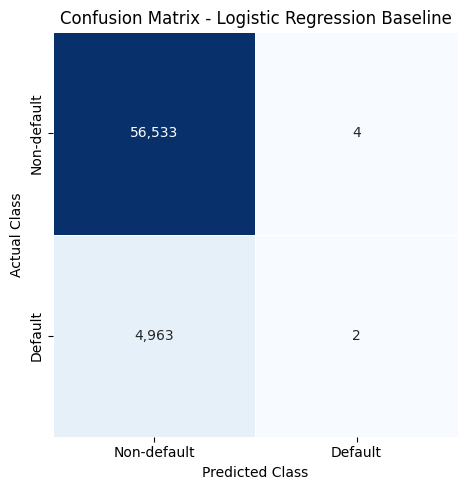

In [23]:
for metric, value in metrics.items():
    print(f"{metric}: {value:.2f}")

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    square=True,
    xticklabels=["Non-default", "Default"],
    yticklabels=["Non-default", "Default"],
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Logistic Regression Baseline")

plt.tight_layout()
plt.show()

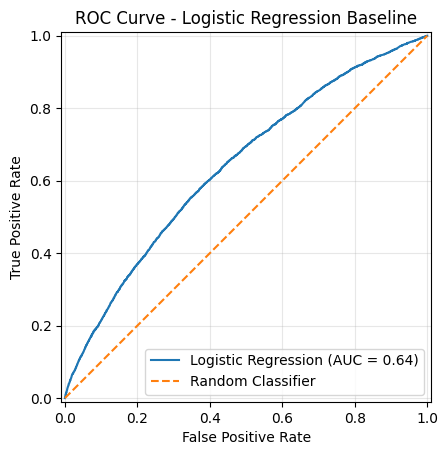

In [27]:
# Calculate ROC-AUC
roc_auc = roc_auc_score(y_val, y_val_proba)

# Plot ROC curve
RocCurveDisplay.from_predictions(
    y_val,
    y_val_proba,
    name=f"Logistic Regression",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression Baseline")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Baseline Logistic Regression:** The model shows moderate discriminatory ability `(ROC-AUC = 0.64 and PR-AUC = 0.14)`, indicating that the selected features contain information associated with default risk. However, using the default classification threshold of 0.5 results in almost no positive predictions, with near-zero recall. Accuracy (~92%) is not informative in this setting, as it is approximately equal to the accuracy of a dummy classifier that predicts all clients as non-default (91.93%).

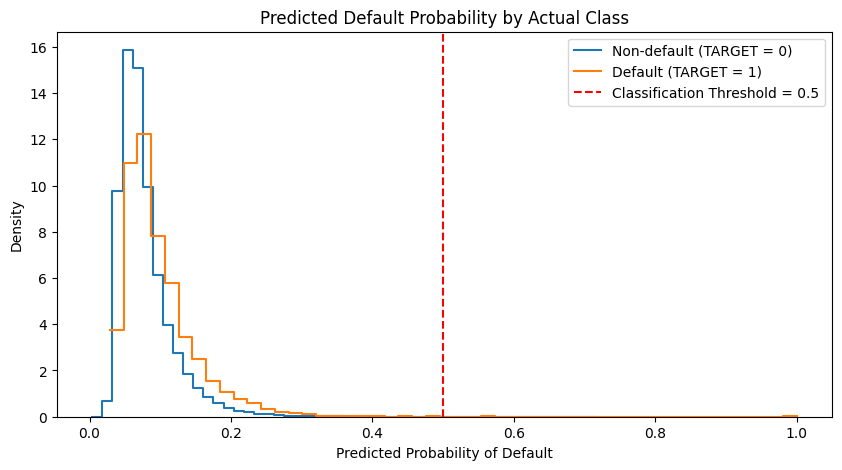

In [ ]:
prob_analysis = pd.DataFrame({
    "TARGET": y_val.to_numpy(),
    "PREDICTED_PROBABILITY": y_val_proba,
})

plt.figure(figsize=(10, 5))

sns.histplot(
    data=prob_analysis[prob_analysis["TARGET"] == 0],
    x="PREDICTED_PROBABILITY",
    bins=50,
    stat="density",
    element="step",
    fill=False,
    label="Non-default (TARGET = 0)",
)

sns.histplot(
    data=prob_analysis[prob_analysis["TARGET"] == 1],
    x="PREDICTED_PROBABILITY",
    bins=50,
    stat="density",
    element="step",
    fill=False,
    label="Default (TARGET = 1)",
)

plt.axvline(
    0.5,
    linestyle="--",
    label="Classification Threshold = 0.5",
    color="red"
)

plt.xlabel("Predicted Probability of Default")
plt.ylabel("Density")
plt.title("Predicted Default Probability by Actual Class")
plt.legend()
plt.show()

In [15]:
prob_summary = (
    prob_analysis
    .groupby("TARGET")["PREDICTED_PROBABILITY"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    ).round(2)
)

prob_summary

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
TARGET,,,,,,,,,,,
0,56537.0,0.08,0.04,0.00,0.05,0.07,0.09,0.13,0.15,0.22,0.72
1,4965.0,0.10,0.05,0.03,0.06,0.09,0.12,0.16,0.20,0.28,1.00


In [16]:
prob_analysis.groupby("TARGET")[
    "PREDICTED_PROBABILITY"
].agg(
    ["mean", "median", "max"]
).round(2)

,mean,median,max
TARGET,,,
0,0.08,0.07,0.72
1,0.10,0.09,1.00


In [17]:
(prob_analysis["PREDICTED_PROBABILITY"] >= 0.5).value_counts()

PREDICTED_PROBABILITY
False    61496
True         6
Name: count, dtype: int64

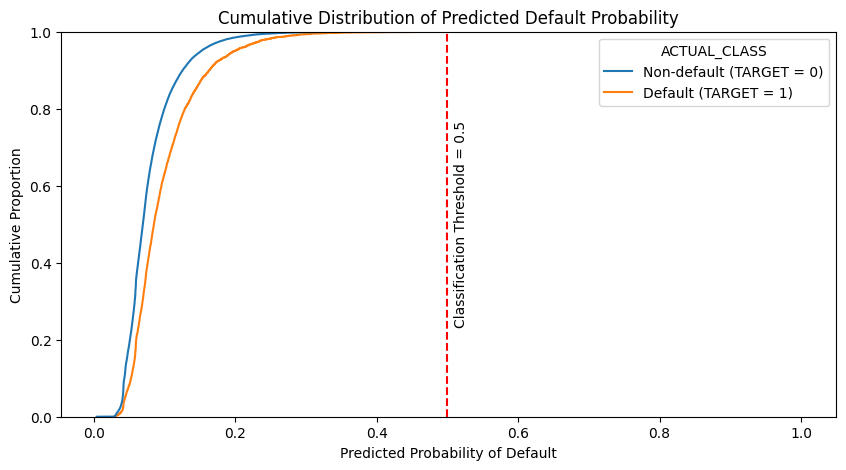

In [18]:
prob_analysis["ACTUAL_CLASS"] = prob_analysis["TARGET"].map({
    0: "Non-default (TARGET = 0)",
    1: "Default (TARGET = 1)",
})

plt.figure(figsize=(10, 5))

sns.ecdfplot(
    data=prob_analysis,
    x="PREDICTED_PROBABILITY",
    hue="ACTUAL_CLASS",
)

plt.axvline(
    0.5,
    linestyle="--",
    color="red",
)
plt.text(
    0.51,
    0.5,
    "Classification Threshold = 0.5",
    rotation=90,
    va="center",
)

plt.xlabel("Predicted Probability of Default")
plt.ylabel("Cumulative Proportion")
plt.title("Cumulative Distribution of Predicted Default Probability")
plt.show()

**Probability Distribution Analysis:** Predicted probabilities are systematically higher for default clients, confirming that the baseline model captures some discriminatory signal. However, the distributions strongly overlap, consistent with the moderate ROC-AUC of 0.64. Almost all observations receive probabilities below 0.5, including 99% of default clients below approximately 0.28, explaining the near-zero recall at the default classification threshold.

# 4. Baseline: Hist Gradient Boosting

In [ ]:
with mlflow.start_run(
    run_name="hist-gradient-boosting-baseline"
):
    # Pipeline
    hgb_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "model",
                HistGradientBoostingClassifier(
                    random_state=42,
                ),
            ),
        ]
    )

    # Parameters
    mlflow.log_params({
        "model": "HistGradientBoostingClassifier",
        "imputer_strategy": "median",
        "threshold": 0.5,
        "random_state": 42,
        "validation_size": 0.25,
        "n_features": len(selected_features),
    })

    # Training
    hgb_pipeline.fit(
        X_train,
        y_train,
    )

    # Predictions
    y_val_pred = hgb_pipeline.predict(X_val)
    y_val_proba = hgb_pipeline.predict_proba(X_val)[:, 1]

    # Metrics
    metrics = {
        "accuracy": accuracy_score(y_val, y_val_pred),
        "precision": precision_score(y_val, y_val_pred),
        "recall": recall_score(y_val, y_val_pred),
        "f1": f1_score(y_val, y_val_pred),
        "roc_auc": roc_auc_score(y_val, y_val_proba),
        "pr_auc": average_precision_score(y_val, y_val_proba),
    }

    mlflow.log_metrics(metrics)

    # Model
    mlflow.sklearn.log_model(
    hgb_pipeline,
    artifact_path="model",
    serialization_format="skops",
    skops_trusted_types=[
        "numpy.dtype",
        "sklearn.ensemble._hist_gradient_boosting.predictor.TreePredictor",
    ],
    )

2026/09/28 20:05:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


accuracy: 0.92
precision: 0.33
recall: 0.00
f1: 0.00
roc_auc: 0.65
pr_auc: 0.15


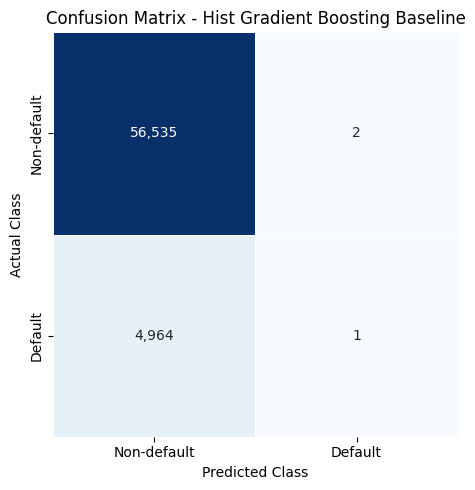

In [12]:
for metric, value in metrics.items():
    print(f"{metric}: {value:.2f}")

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    square=True,
    xticklabels=["Non-default", "Default"],
    yticklabels=["Non-default", "Default"],
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Hist Gradient Boosting Baseline")

plt.tight_layout()
plt.show()

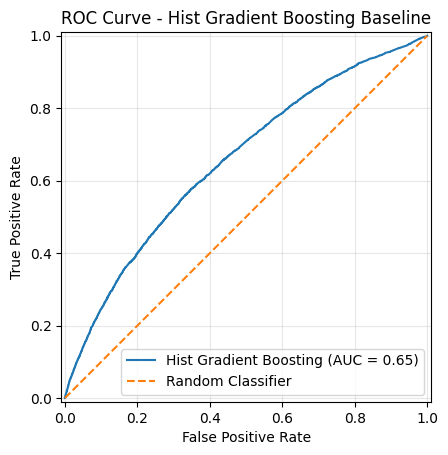

In [13]:
# Calculate ROC-AUC
roc_auc = roc_auc_score(y_val, y_val_proba)

# Plot ROC curve
RocCurveDisplay.from_predictions(
    y_val,
    y_val_proba,
    name=f"Hist Gradient Boosting",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hist Gradient Boosting Baseline")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Hist Gradient Boosting Baseline**: A tree-based model was evaluated to test whether capturing non-linear relationships and interactions between features could improve predictive performance compared with the Logistic Regression baseline, while keeping the same feature set and train/validation split.

The Hist Gradient Boosting model achieved ROC-AUC = 0.65 and PR-AUC = 0.15, representing only a small improvement over the Logistic Regression baseline. At the default threshold of 0.5, the model predicted almost all observations as non-default, resulting in near-zero recall.

Overall, the limited improvement from a more flexible model suggests that model complexity alone is not sufficient with the current feature set.

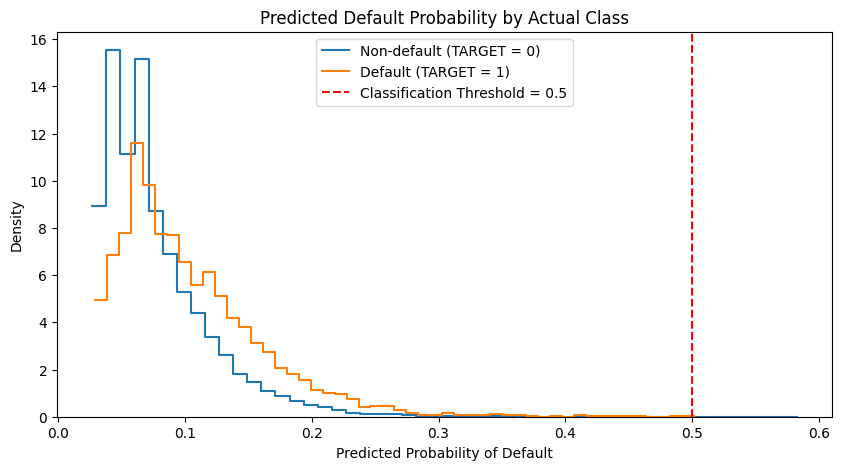

In [15]:
prob_analysis = pd.DataFrame({
    "TARGET": y_val.to_numpy(),
    "PREDICTED_PROBABILITY": y_val_proba,
})

plt.figure(figsize=(10, 5))

sns.histplot(
    data=prob_analysis[prob_analysis["TARGET"] == 0],
    x="PREDICTED_PROBABILITY",
    bins=50,
    stat="density",
    element="step",
    fill=False,
    label="Non-default (TARGET = 0)",
)

sns.histplot(
    data=prob_analysis[prob_analysis["TARGET"] == 1],
    x="PREDICTED_PROBABILITY",
    bins=50,
    stat="density",
    element="step",
    fill=False,
    label="Default (TARGET = 1)",
)

plt.axvline(
    0.5,
    linestyle="--",
    label="Classification Threshold = 0.5",
    color="red"
)

plt.xlabel("Predicted Probability of Default")
plt.ylabel("Density")
plt.title("Predicted Default Probability by Actual Class")
plt.legend()
plt.show()

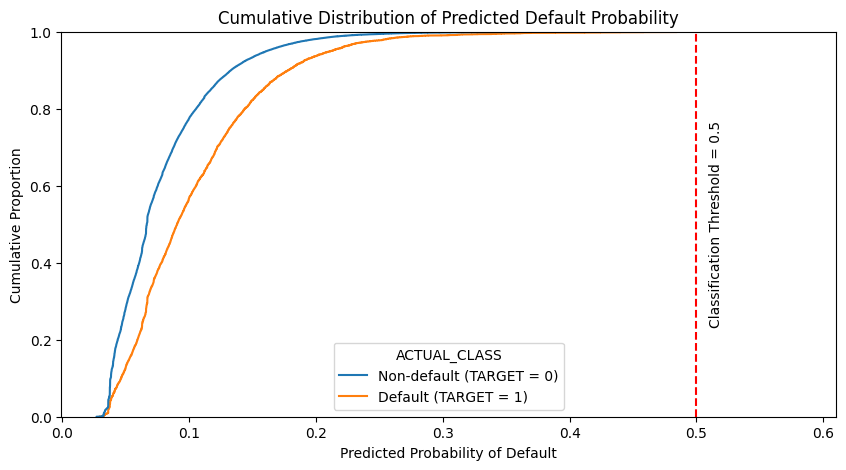

In [16]:
prob_analysis["ACTUAL_CLASS"] = prob_analysis["TARGET"].map({
    0: "Non-default (TARGET = 0)",
    1: "Default (TARGET = 1)",
})

plt.figure(figsize=(10, 5))

sns.ecdfplot(
    data=prob_analysis,
    x="PREDICTED_PROBABILITY",
    hue="ACTUAL_CLASS",
)

plt.axvline(
    0.5,
    linestyle="--",
    color="red",
)
plt.text(
    0.51,
    0.5,
    "Classification Threshold = 0.5",
    rotation=90,
    va="center",
)

plt.xlabel("Predicted Probability of Default")
plt.ylabel("Cumulative Proportion")
plt.title("Cumulative Distribution of Predicted Default Probability")
plt.show()

**Conclusion**

Increasing model flexibility from Logistic Regression to Hist Gradient Boosting produced only marginal improvements in discrimination. Both models show similar probability distributions, with substantial overlap between default and non-default clients and only a modest shift toward higher scores for default cases. This suggests that the current feature set, rather than model complexity alone, may be the main limiting factor.